## Librerias

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rapidfuzz import process, fuzz


## Funciones Auxiliares

In [5]:
## Graficas de variables cualitativas con porcentaje
def plot_categorical_summary(df, columna):
    # Convertir a string para evitar errores de tipo
    datos = df[columna].astype(str)

    # Calcular porcentajes
    porcentaje = datos.value_counts(normalize=True, dropna=False) * 100
    categorias = porcentaje.index
    valores = porcentaje.values

    # Gráfico
    plt.figure(figsize=(8, 4))
    barras = plt.bar(categorias, valores, color='skyblue', edgecolor='black')

    for i, bar in enumerate(barras):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{valores[i]:.1f}%',
                 ha='center', fontsize=10)

    plt.title(columna)
    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Categorías')
    plt.xticks(rotation=45)
    plt.ylim(0, max(valores) + 10)
    plt.tight_layout()
    plt.show()

In [6]:
df = pd.read_excel('../data/CARACTERIZACION 1 (1).xlsx')
df.head()

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,NOMBRE,UNIDAD,PENSUM,FECHA_ACTUALIZACION,ESTADO SOCIODEMOGRAFICO,ESTADO VULNERABILIDAD,ESTADO CONDICIONES DE SALUD,...,TRATAMIENTO_MEDICO,FECHA_DIAGNOSTICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
0,CC,1069734259,M,JEFERSSON GIOVANNY PICO ACOSTA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,112,190,NaN,NaN,NaN
1,CC,1069735295,F,MAYERLI YAQUELIN PARRA MORA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CC,1069734073,F,YEIMY LORENA PIÑEROS GUTIERREZ,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-01 11:38:27.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,Si,2007-05-10 00:00:00,Nunca,No,Nunca,52,1.60,Nunca,NaN,NaN
3,CC,1069735681,F,CLAUDIA LORENA BOLIVAR TUNAROSA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CC,1069737604,M,KEVIN DAVID CRUZ MELO,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-24 12:19:26.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,No,NaN,Nunca,No,Nunca,104,1.78,Nunca,NaN,NaN


In [7]:
df_2 = pd.read_excel('../data/desempeño_areas_formacion.xlsx')
df_2.head()

,PERIODO,FACULTAD,UNIDAD,PENSUM,DOCUMENTO,NOMBRES,MATRICULA_ACTUAL,SITUACION_ACTUAL,CATEGORIA_ACTUAL,CIENCIAS BÁSICAS,CIENCIAS BÁSICAS DE INGENIERÍA,INGENIERÍA APLICADA,INSTITUCIONAL,TOTAL_BAJO_RENDIMIENTO_REA,DESERTA
0,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000136072,FORERO HERRERA TANIA NICKOLL,SIN MATRICULA,ACTIVO,CONTINUIDAD ACADEMICA - EGRESADO,3.553846,3.956154,3.951915,3.897200,2,0
1,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000320087,MESA BLANCO LEONARDO JUAN,SIN MATRICULA,ACTIVO,ANTIGUO,3.310833,3.297368,3.661538,3.761000,9,0
2,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000592838,BAUTISTA DIAZ DANIEL EDUARDO,SIN MATRICULA,ACTIVO,CONTINUIDAD ACADEMICA - EGRESADO,3.475000,3.625714,3.960278,3.890833,6,0
3,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1001346777,SUAREZ HEREDIA JUAN SEBASTIAN,SIN MATRICULA,EXCLUIDO BAJO RENDIMIENTO,ANTIGUO,3.171429,2.900000,3.100000,3.000000,7,1
4,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1003515700,ESCOBAR VASQUEZ JENIFFER DAYANA,SIN MATRICULA,EXCLUIDO BAJO RENDIMIENTO,ANTIGUO,3.328571,2.623529,3.900000,3.485714,10,1


In [8]:
# Obtener los valores únicos de cada columna
documentos_df = set(df['DOCUMENTO'].unique())
documentos_df2 = set(df_2['DOCUMENTO'].unique())

# Calcular la intersección
documentos_comunes = documentos_df.intersection(documentos_df2)

# Mostrar la cantidad de documentos que coinciden
print(f"Número de DOCUMENTO que coinciden: {len(documentos_comunes)}")


Número de DOCUMENTO que coinciden: 767


In [9]:
df_caracterizacion = df[df['DOCUMENTO'].isin(documentos_comunes)]

In [10]:
df_caracterizacion.head(5)

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,NOMBRE,UNIDAD,PENSUM,FECHA_ACTUALIZACION,ESTADO SOCIODEMOGRAFICO,ESTADO VULNERABILIDAD,ESTADO CONDICIONES DE SALUD,...,TRATAMIENTO_MEDICO,FECHA_DIAGNOSTICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
4,CC,1069737604,M,KEVIN DAVID CRUZ MELO,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-24 12:19:26.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,No,NaN,Nunca,No,Nunca,104,1.78,Nunca,NaN,NaN
9,CC,1026290752,M,WILLIAM ESTEBAN BRICEÑO CASTRILLON,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,2023-06-23 18:49:28.000,INFORMACIÓN SOCIODEMOGRÁFICA: aprobado,VULNERABILIDAD: pendiente de revision,CONDICIONES DE SALUD: pendiente de revision,...,No,NaN,Nunca,No,Una vez al mes,87,1.75,Nunca,NaN,NaN
12,CC,1069750774,M,HARVEY GUSTAVO VARGAS GUIZA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,No,NaN,Nunca,No,Nunca,87,1.74,Nunca,NaN,NaN
21,CC,1069747785,M,JUAN CAMILO VANEGAS FISCAL,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,No,NaN,Nunca,No,Una vez al mes,80,170,Nunca,NaN,NaN
30,CC,1069760977,M,EDGAR ORLANDO ROMERO MORA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,NaN,NaN,NaN,NaN,...,No,NaN,Nunca,No,Una vez al mes,68,1.72,Nunca,NaN,NaN


In [11]:
df_caracterizacion.info()

<class 'pandas.core.frame.DataFrame'>
Index: 835 entries, 4 to 2375
Data columns (total 85 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   TIPO_DOCUMENTO                      835 non-null    object 
 1   DOCUMENTO                           835 non-null    int64  
 2   GENERO                              835 non-null    object 
 3   NOMBRE                              835 non-null    object 
 4   UNIDAD                              835 non-null    object 
 5   PENSUM                              835 non-null    object 
 6   FECHA_ACTUALIZACION                 500 non-null    object 
 7   ESTADO SOCIODEMOGRAFICO             500 non-null    object 
 8   ESTADO VULNERABILIDAD               500 non-null    object 
 9   ESTADO CONDICIONES DE SALUD         500 non-null    object 
 10  UBICACION_SEMESTRAL                 835 non-null    int64  
 11  CELULAR                             821 non-null 

In [13]:
df_caracterizacion.isnull().sum()/len(df_caracterizacion)*100

TIPO_DOCUMENTO                      0.000000
DOCUMENTO                           0.000000
GENERO                              0.000000
NOMBRE                              0.000000
UNIDAD                              0.000000
                                     ...    
PESO                                0.479042
ESTATURA                            0.479042
CONSUME_SUSTANCIAS_PSICOACTIVAS     4.311377
TIENE_TITULO                       49.820359
OTROS_ESTUDIOS                     49.820359
Length: 85, dtype: float64

## ELIMINACIÓN DE VARIABLES
A continuación se dispone a eliminar aquellas variables que en principios no generan información valiosa para el modelo ya sea por que son ID´s, nombre, variables que toman siempre el mismo valor entre otras. Es de resaltar que atravez del cuadernillo se iran elimnando otras variables que al analizarlas no hacen sentido o se unen con otra variable.

1.   UNIDAD = Siempre toma el mismo valor
2.   PENSUM = Siempre toma el mismo valor
3.   NOMBRE = No es una variable adecuada para el modelo
4.   FECHA_ACTUALIZACIÓN = No es una variable adecuada para el modelo
5.   ESTADO SOCIODEMOGRAFICO = Muchos datos faltantes y lo valores que toma es un estado de revisión
6.   ESTADO VULNERABILIDAD = Muchos datos faltantes y lo valores que toma es un estado de revisión
7.   ESTADO CONDICIONES DE SALUD = Muchos datos faltantes y lo valores que toma es un estado de revisión
8. CELULAR = No es una variable adecuada para el modelo
9. EMAIL_INSTITUCIONAL = No es una variable adecuada para el modelo
10. NOMBRE_CONTACTO_EMERGENCIA = No es una variable adecuada para el modelo
11. CELULAR_CONTACTO_EMERGENCIA = No es una variable adecuada para el modelo
12. PARENTESCO_CONTACTO_EMERGENCIA = No es una variable adecuada para el modelo
13. ARL = Tiene muchos valores vacios
14. DISCAPACIDAD_AUDITIVA_CASTELLANO = Muchos datos faltantes y el valor que toma no es determinante
15. DISCAPACIDAD_AUDITIVA_LENGUASENAS = Muchos datos faltantes y el valor que toma no es determinante
16. AYUDA_AUDITIVA = Muchos datos faltantes y el valor que toma no es determinante
17. DISCAPACIDAD_VISUAL_BAJAVISION = Muchos datos faltantes y el valor que toma no es determinante
18. DISCAPACIDAD_VISUAL_CEGUERA = Muchos datos faltantes y el valor que toma no es determinante
19. FECHA_DIAGNOSTICO = No es una variable adecuada para el modelo

In [14]:
Eliminar = ["UNIDAD", "PENSUM", "NOMBRE", "ESTADO SOCIODEMOGRAFICO", "ESTADO VULNERABILIDAD", "ESTADO CONDICIONES DE SALUD",
            "CELULAR", "EMAIL_INSTITUCIONAL", "NOMBRE_CONTACTO_EMERGENCIA", "CELULAR_CONTACTO_EMERGENCIA", "PARENTESCO_CONTACTO_EMERGENCIA", "ARL",
            "DISCAPACIDAD_AUDITIVA_CASTELLANO", "DISCAPACIDAD_AUDITIVA_LENGUASENAS", "AYUDA_AUDITIVA", "DISCAPACIDAD_VISUAL_BAJAVISION", "DISCAPACIDAD_VISUAL_CEGUERA",
            "FECHA_DIAGNOSTICO"]

df_caracterizacion.drop(Eliminar, axis=1, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_624\2018384542.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion.drop(Eliminar, axis=1, inplace=True)


In [15]:
df_caracterizacion

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,FECHA_ACTUALIZACION,UBICACION_SEMESTRAL,ORIENTACION_SEXUAL,MEDIO_TRANSPORTE,FRECUENCIA_TRANSPORTE,HORARIO_INICIO_TRANSPORTE,HORARIO_FIN_TRANSPORTE,...,ENFERMEDADES_CRONICAS,TRATAMIENTO_MEDICO,FUMA,ESTA_EMBARAZO,CONSUME_ALCOHOL,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS
4,CC,1069737604,M,2023-06-24 12:19:26.000,2,Heterosexualidad,Bicicleta,4 veces al dia,06:30:00,18:00:00,...,ul,No,Nunca,No,Nunca,104,1.78,Nunca,NaN,NaN
9,CC,1026290752,M,2023-06-23 18:49:28.000,9,Heterosexualidad,Moto,1 vez al dia,12:00:00,22:00:00,...,ul,No,Nunca,No,Una vez al mes,87,1.75,Nunca,NaN,NaN
12,CC,1069750774,M,NaN,9,NaN,A pie,1 vez al dia,05:30:00,18:00:00,...,NaN,No,Nunca,No,Nunca,87,1.74,Nunca,NaN,NaN
21,CC,1069747785,M,NaN,5,NaN,A pie,mas de 5 veces al dia,06:00:00,21:00:00,...,ul,No,Nunca,No,Una vez al mes,80,170,Nunca,NaN,NaN
30,CC,1069760977,M,NaN,9,Heterosexualidad,A pie,2 veces al dia,06:00:00,21:00:00,...,ul,No,Nunca,No,Una vez al mes,68,1.72,Nunca,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,CC,11202693,M,2023-06-08 11:35:46.000,6,Heterosexualidad,Servicio público,2 veces al dia,06:00:00,20:00:00,...,ul,No,Nunca,No,Nunca,90,174,Nunca,NaN,NaN
1588,CC,1023970909,M,2023-06-20 13:26:05.000,0,Heterosexualidad,Servicio público,1 vez al dia,06:30:00,17:30:00,...,ul,No,Nunca,No,Una vez al mes,64,1.75,Nunca,NaN,NaN
1701,CC,1007664640,M,NaN,2,Heterosexualidad,Servicio público,1 vez al dia,06:30:00,17:00:00,...,ul,No,Nunca,No,Nunca,75,175,Nunca,NaN,NaN
2015,CC,1000693735,F,2024-07-04 16:11:17.000,0,Heterosexualidad,Servicio público,2 veces al dia,11:30:00,18:30:00,...,ul,No,Nunca,No,Una vez al mes,85,1.67,Nunca,NaN,NaN


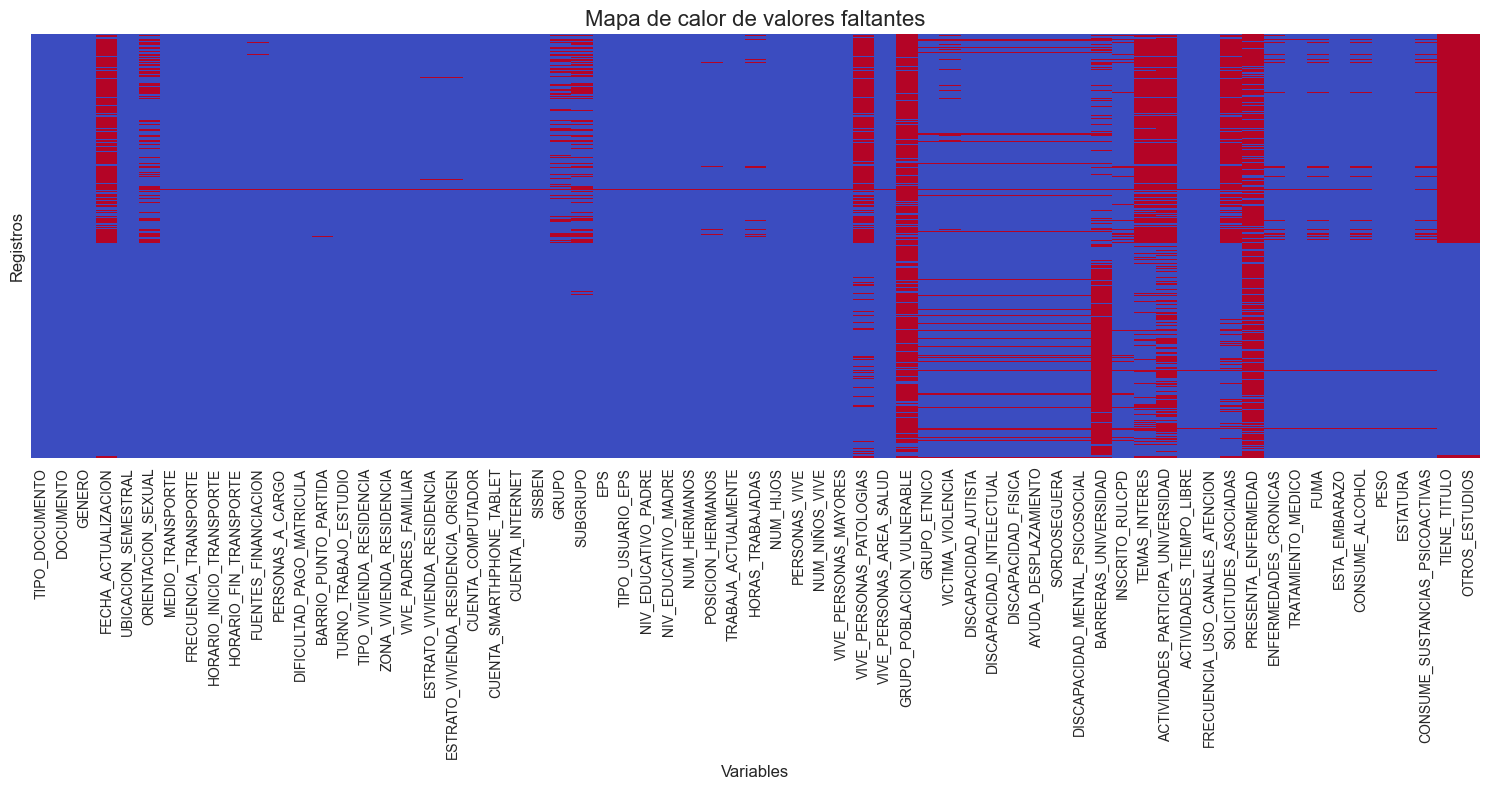

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_caracterizacion.isnull(),
            cbar=False,
            cmap='coolwarm',
            yticklabels=False)

plt.title("Mapa de calor de valores faltantes", fontsize=16)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Registros", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Se revisara aquellas filas que contiene menos 40% de valores faltantes para eliminarlas ya que si se imputa por columna ese registro sería artificial ya que seria el resultado de solo imputaciones.

In [91]:
# Calcular el porcentaje de valores faltantes por fila
porcentaje_faltantes = df_caracterizacion.isnull().mean(axis=1)

# Identificar las filas con más del 70% de valores faltantes
filas_con_mas_de_40 = df_caracterizacion[porcentaje_faltantes > 0.4]


In [90]:
filas_con_mas_de_40

,TIPO_DOCUMENTO,DOCUMENTO,GENERO,FECHA_ACTUALIZACION,UBICACION_SEMESTRAL,ORIENTACION_SEXUAL,MEDIO_TRANSPORTE,FRECUENCIA_TRANSPORTE,HORARIO_INICIO_TRANSPORTE,HORARIO_FIN_TRANSPORTE,...,PESO,ESTATURA,CONSUME_SUSTANCIAS_PSICOACTIVAS,TIENE_TITULO,OTROS_ESTUDIOS,ORIENTACION_CAT,COMUNA_PUNTO_PARTIDA,ACCESO_TECNOLOGICO,NIV_EDUCATIVO_PADRE_CAT,NIV_EDUCATIVO_MADRE_CAT
326,CC,1000589613,M,2024-06-28 14:00:29.000,9,No responde,A pie,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,No responde,No definido,Solo uno,Superior,Superior
438,CC,1069763449,M,NaN,1,No responde,A pie,NaN,NaN,NaN,...,60,180,NaN,NaN,NaN,No responde,No definido,Solo uno,Superior,Superior
479,CC,1006692896,M,NaN,2,No responde,A pie,NaN,NaN,NaN,...,65,1.63,NaN,NaN,NaN,No responde,No definido,Solo uno,Superior,Superior


In [19]:
#df_caracterizacion.drop(filas_con_mas_de_40.index, inplace=True)

Se escoje un 40% por criterio arbitrario como el fin es poder modelar la deserción si se amplia el umbral se perderian muchos registros.

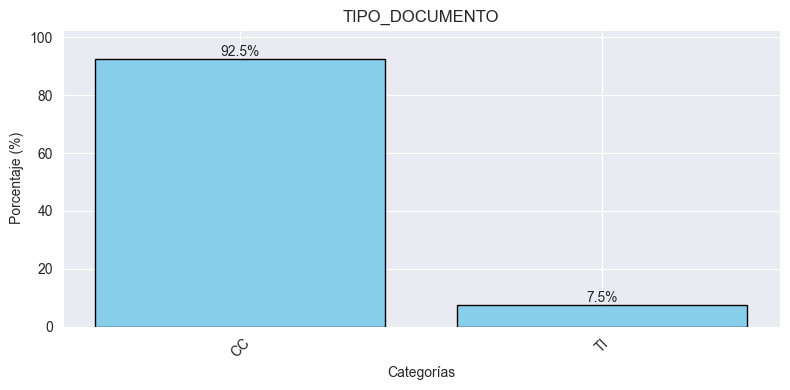

In [20]:
plot_categorical_summary(df_caracterizacion, 'TIPO_DOCUMENTO')

Esta variable se elimina por que se considera con poco poder predictivo.

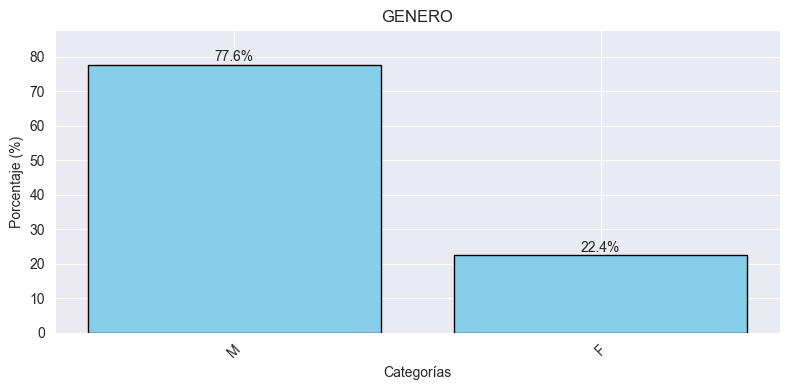

In [21]:
plot_categorical_summary(df_caracterizacion, 'GENERO')


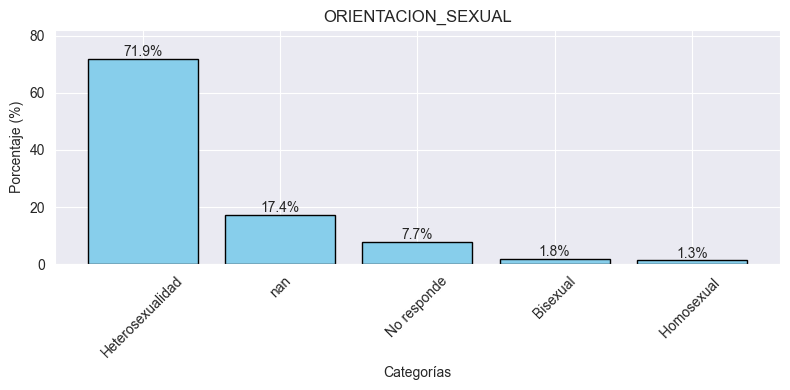

In [22]:
plot_categorical_summary(df_caracterizacion, 'ORIENTACION_SEXUAL')


Se considera una variable importante sin embargo se realizará una recategorización de los valores para capturar mejorar la información que ofrece la variable. Por otro lado, puede suceder que la decisión de "no responder" este correlacionado por una percepción de estigmatización o desconfianza institiucional o falta de compromiso con la encuesta, sin embargo, se mantiene

In [23]:
df_caracterizacion['ORIENTACION_SEXUAL'] = df_caracterizacion['ORIENTACION_SEXUAL'].fillna('No responde')
def agrupar_orientacion(valor):
    if valor in ['Homosexual', 'Bisexual']:
        return 'Diversa'
    elif valor == 'Heterosexualidad':
        return 'Heterosexual'
    else:
        return 'No responde'

df_caracterizacion['ORIENTACION_CAT'] = df_caracterizacion['ORIENTACION_SEXUAL'].apply(agrupar_orientacion)

C:\Users\User\AppData\Local\Temp\ipykernel_624\1782198930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ORIENTACION_SEXUAL'] = df_caracterizacion['ORIENTACION_SEXUAL'].fillna('No responde')
C:\Users\User\AppData\Local\Temp\ipykernel_624\1782198930.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ORIENTACION_CAT'] = df_caracterizacion['ORIENTACION_SEXUAL'].apply(agrupar_orientacion)


In [24]:
df_caracterizacion['ORIENTACION_CAT'].value_counts()

ORIENTACION_CAT
Heterosexual    600
No responde     220
Diversa          15
Name: count, dtype: int64

In [26]:
df_caracterizacion["MEDIO_TRANSPORTE"].value_counts()

MEDIO_TRANSPORTE
Servicio público    394
A pie               370
Bicicleta            33
Moto                 26
Vehículo propio       7
,                     2
Name: count, dtype: int64

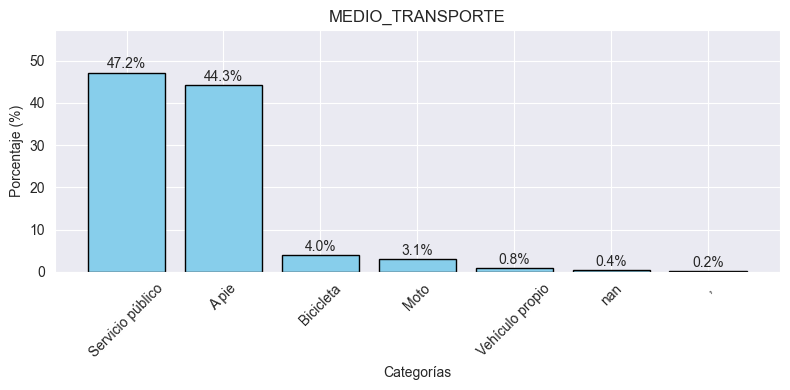

In [25]:
plot_categorical_summary(df_caracterizacion, 'MEDIO_TRANSPORTE')

Se recategoriza algunos valores con el fin de simplificar y mantener valor predictivo

In [27]:
# 1. Reemplazar categorías específicas
df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].replace({
    'Moto': 'Vehículo motorizado',
    'Vehículo propio': 'Vehículo motorizado',
    ',': 'A pie'  # coma suelta como categoría inválida
})

# 2. Reemplazar NaN por 'A pie'
df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].fillna('A pie')

C:\Users\User\AppData\Local\Temp\ipykernel_624\2865197349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].replace({
C:\Users\User\AppData\Local\Temp\ipykernel_624\2865197349.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['MEDIO_TRANSPORTE'] = df_caracterizacion['MEDIO_TRANSPORTE'].fillna('A pie')


In [28]:
df_caracterizacion['MEDIO_TRANSPORTE'].value_counts()

MEDIO_TRANSPORTE
Servicio público       394
A pie                  375
Vehículo motorizado     33
Bicicleta               33
Name: count, dtype: int64

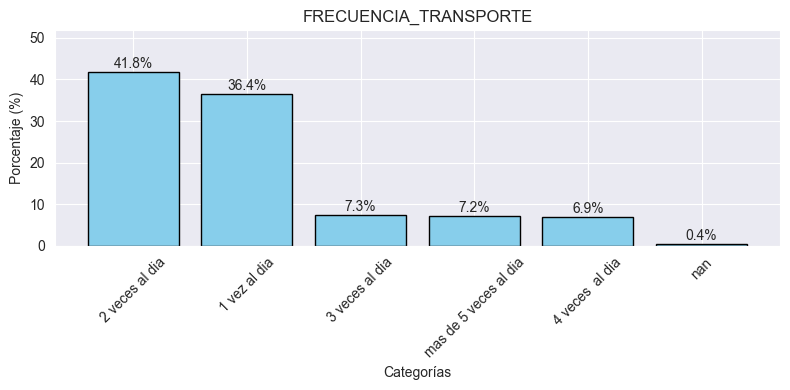

In [29]:
plot_categorical_summary(df_caracterizacion, 'FRECUENCIA_TRANSPORTE')


Se va recategorizar entendiendo que alguna categorias tienen poca representación lo que introduce ruido y sparsity para modelos predictivos

In [30]:
moda = df['FRECUENCIA_TRANSPORTE'].mode()[0]
df['FRECUENCIA_TRANSPORTE'] = df['FRECUENCIA_TRANSPORTE'].fillna(moda)

In [32]:
# Paso 2: Función para recategorizar la frecuencia de transporte
def recategorizar_frecuencia(valor):
    if valor in ['1 vez al día', '2 veces al día']:
        return 'Baja frecuencia'
    elif valor in ['3 veces al día', '4 veces al día', 'mas de 5 veces al día']:
        return 'Alta frecuencia'
    else:
        return 'Otro'  # Por si hay valores inesperados

# Paso 3: Aplicar la recategorización
df['FRECUENCIA_TRANSPORTE'] = df['FRECUENCIA_TRANSPORTE'].apply(recategorizar_frecuencia)

In [33]:
df_caracterizacion['MEDIO_TRANSPORTE'].value_counts()

MEDIO_TRANSPORTE
Servicio público       394
A pie                  375
Vehículo motorizado     33
Bicicleta               33
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_624\3964928011.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


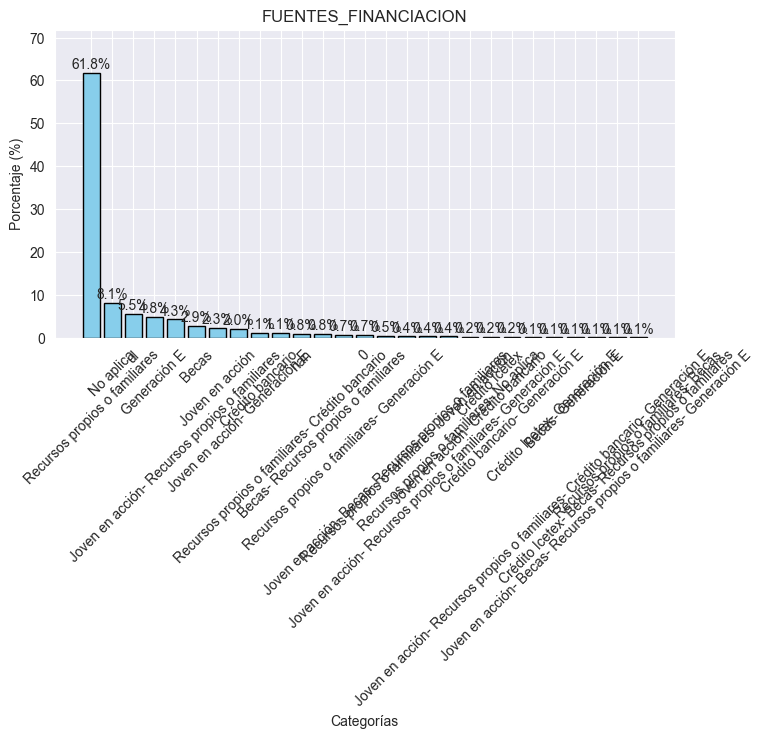

In [34]:
plot_categorical_summary(df_caracterizacion, 'FUENTES_FINANCIACION')

In [36]:
df_caracterizacion[ 'FUENTES_FINANCIACION'].value_counts()

FUENTES_FINANCIACION
Recursos propios o familiares                                                     516
No aplica                                                                          68
ul                                                                                 46
Generación E                                                                       40
Joven en acción- Recursos propios o familiares                                     36
Becas                                                                              24
Joven en acción                                                                    19
Joven en acción- Generación E                                                      17
Crédito bancario                                                                    9
Recursos propios o familiares- Crédito bancario                                     9
Becas- Recursos propios o familiares                                                7
Recursos propios o familiares- Ge

Se considera una recategorización de los valores de esta variable existe mucho ruido pero se considera importante para el desarrollo del modelo

In [37]:
def recategorizar_fuente(valor):
    valor = str(valor).lower()

    if any(palabra in valor for palabra in ['beca', 'generación e', 'joven en acción']):
        return 'Beca'
    elif any(palabra in valor for palabra in ['crédito', 'icetex']):
        return 'Crédito'
    elif any(palabra in valor for palabra in ['recurso', 'familiar']):
        return 'Recursos propios'
    elif valor.strip() in ['ul', '0', 'nan', 'no aplica', '']:
        return 'Otro / No aplica'
    else:
        return 'Otro / No aplica'  # para cualquier valor inesperado


In [41]:
df_caracterizacion['FUENTES_FINANCIACION'] = df_caracterizacion['FUENTES_FINANCIACION'].apply(recategorizar_fuente)
print(df_caracterizacion['FUENTES_FINANCIACION'].value_counts())

FUENTES_FINANCIACION
Recursos propios    519
Beca                169
Otro / No aplica    127
Crédito              20
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_624\3368156425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['FUENTES_FINANCIACION'] = df_caracterizacion['FUENTES_FINANCIACION'].apply(recategorizar_fuente)


In [46]:
df_caracterizacion['BARRIO_PUNTO_PARTIDA'].value_counts(dropna=False).to_dict()

{'Balmoral': 37,
 'ebenezer': 19,
 'centro': 19,
 'Pekin': 15,
 'Fusacatan': 13,
 'Cedritos': 11,
 'arbelaez': 10,
 'Aires del quinini': 8,
 'Santander': 7,
 'Gaitan ': 7,
 'Coburgo': 7,
 'pekin': 7,
 ' bonanza ': 6,
 'San Antonio': 6,
 'la florida': 6,
 'Gaitan': 6,
 'los robles': 6,
 'Emilio Sierra': 6,
 'gran colombia': 6,
 'las delicias': 6,
 'San Fernando': 5,
 'la pampa': 5,
 'villa natalia': 5,
 'fusacatan': 5,
 'Macarena': 5,
 'Maiz Amarillo': 5,
 'gaitan': 5,
 'Luxemburgo': 4,
 'Sauces': 4,
 'Bonet': 4,
 'Pablo bello': 4,
 'Marsella': 4,
 'PRADOS DE ALTAGRACIA': 4,
 'El vergel': 4,
 nan: 4,
 'Aguabonita-Silvania': 4,
 'Santa Barbara': 4,
 'Comuneros': 4,
 'La independencia': 4,
 'Pardo leal': 4,
 'El eden': 4,
 'Olaya': 4,
 'GAITAN': 4,
 'pardo leal': 3,
 'CAMINO REAL': 3,
 'altos de pekin': 3,
 'san fernando': 3,
 'NINGUNO': 3,
 'Nuevo Balmoral': 3,
 'chinauta': 3,
 'mirador de san luis': 3,
 'olaya': 3,
 'cedritos': 3,
 'obrero': 3,
 'Fusacatán': 3,
 'Camino real': 3,
 'Anto

In [122]:
df_caracterizacion['BARRIO_PUNTO_PARTIDA'] = (
    df_caracterizacion['BARRIO_PUNTO_PARTIDA']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)

C:\Users\User\AppData\Local\Temp\ipykernel_624\4163240614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['BARRIO_PUNTO_PARTIDA'] = (


In [118]:
comunas_fusagasuga = {
    'Comuna Centro': [
        'santander', 'emilio sierra', 'centro', 'olaya', 'luxemburgo', 'potosí', 'barrio centro', 'fusagasuga'
    ],
    'Comuna Norte': [
        'el progreso', 'josé antonio galán', 'la cabaña', 'nueva esperanza', 'la esmeralda',
        'villa armerita', 'san antonio', 'gaitán i', 'gaitán ii', 'gaitan ii', 'gaitan 2etapa','la independencia', 'gaitan'
        'gaitán', 'galan', 'galan bajo', 'gaitan', 'gaitán', 'galan bajo',
        'el edén', 'villa natalia', 'la florida', 'los andes', 'santa librada',
        'mi tesoro', 'villa rosalía', 'el rosal', 'villas de san diego i', 'villas de san diego ii',
        'monte verde', 'los fundadores', 'la palma', 'carlos lleras', 'porvenir la salle', 'el lucero', 'la palma 2', 'la palma 3'
    ],
    'Comuna Occidental': [
        'san mateo', 'manila', 'santa anita', 'san jorge', 'marsella', 'comboy', 'mandalay',
        'nuevo balmoral', 'el caney', 'fontanar', 'antiguo balmoral', 'villa alix', 'piedra grande', 'barrio balmoral',
        'santa ana campestre', 'villa country', 'quintas de balmoral', 'el manantial', 'santa clara',
        'siboney', 'teresita i', 'teresita ii', 'la marsella', 'barrio bonanza', 'bonanza','balmoral',
    ],
    'Comuna Oriental': [
        'pekín', 'cedritos', 'coburgo', 'bosque bonnet', 'el tejar', 'los robles', 'bella vista',
        'santa maría de los ángeles', 'antonio nariño', 'los sauces', 'altos de pekín', 'bonet', 'sauces', 'vereda los sauces finca las delicias',
        'villa de los sutagaos', 'villa aranzazu', 'altos de pekin', 'pekin', 'pekin antiguo', 'pekin ladrillera', 'barrio los sauces', 'boneth', 'bosque bonet', 'cedritos fusagasugá','pekin'
    ],
    'Comuna Sur Occidental': [
        'llano largo', 'la pampa', 'la venta', 'cooviprof', 'maíz amarillo', 'ciudad eben-ezer',
        'gran colombia', 'caminos de llano largo', 'llano verde', 'villa celeste', 'las brisas',
        'leidy di', 'pedregal de san luis', 'parques de occidente i', 'parques de occidente ii',
        'el oasis', 'la primavera', 'llano grande', 'asoveinte', 'san diego la venta',
        'balcones de san josé', 'villas de la pampa', 'villa rosita', 'los girasoles', 'ciudad jardín',
        'cádiz', 'nueva campiña', 'ciudadela comfenalco', 'san francisco', 'cámbulos',
        'san martín de los olivos'
    ],
    'Comuna Sur Oriental': [
        'balmoral', 'fusacatán', 'obrero', 'los comuneros', 'la macarena', 'el vergel', 'balmoral fusagasuga', 'barmoral',
        'san fernando', 'pedro pablo bello', 'jaime pardo leal', 'prados de bethel', 'el mirador', 'barmoral', 'barrio balmoral'
        'las delicias', 'las américas', 'camino real', 'santa bárbara', 'villa leidy', 'macarena', 'barrio la macarena'
        'prados de alta gracia', 'bosques del oriente', 'aires de quinini', 'popular obrero',
        'santa rosa', 'bethel bajo', 'la alejandra', 'sauces bajo', 'barrio la macarena'
    ]
}


In [119]:
def asignar_comuna(barrio):
    for comuna, barrios in comunas_fusagasuga.items():
        if barrio in barrios:
            return comuna
    return 'Sin agrupar'


In [114]:
df_caracterizacion['COMUNA'] = df_caracterizacion['BARRIO_PUNTO_PARTIDA'].apply(asignar_comuna)

C:\Users\User\AppData\Local\Temp\ipykernel_624\1755687557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['COMUNA'] = df_caracterizacion['BARRIO_PUNTO_PARTIDA'].apply(asignar_comuna)


In [120]:
df_caracterizacion['COMUNA'].value_counts()

COMUNA
Sin agrupar              454
Comuna Oriental           84
Comuna Norte              82
Comuna Occidental         80
Comuna Sur Oriental       55
Comuna Centro             52
Comuna Sur Occidental     28
Name: count, dtype: int64

In [125]:
df_caracterizacion['BARRIO_PUNTO_PARTIDA'].value_counts()

BARRIO_PUNTO_PARTIDA
balmoral                                     39
pekin                                        25
gaitan                                       23
fusacatan                                    23
ebenezer                                     19
                                             ..
siboney                                       1
0                                             1
san diego                                     1
urbanización villa de los sutagaos casa 3     1
rosa blanca                                   1
Name: count, Length: 328, dtype: int64

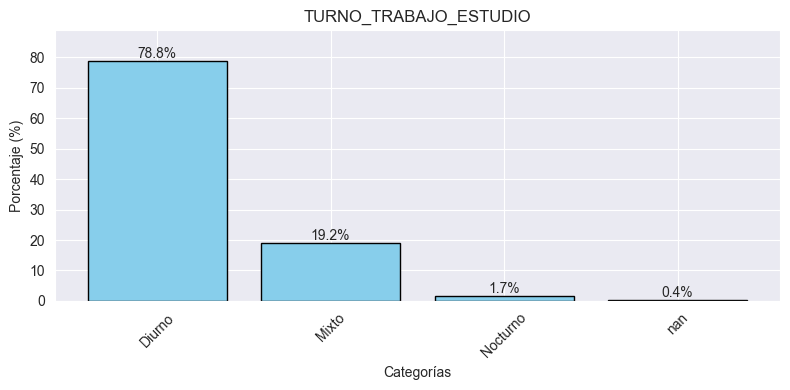

In [58]:
plot_categorical_summary(df_caracterizacion,'TURNO_TRABAJO_ESTUDIO')

In [56]:
df_caracterizacion['TURNO_TRABAJO_ESTUDIO'].value_counts()

TURNO_TRABAJO_ESTUDIO
Diurno      658
Mixto       160
Nocturno     14
Name: count, dtype: int64

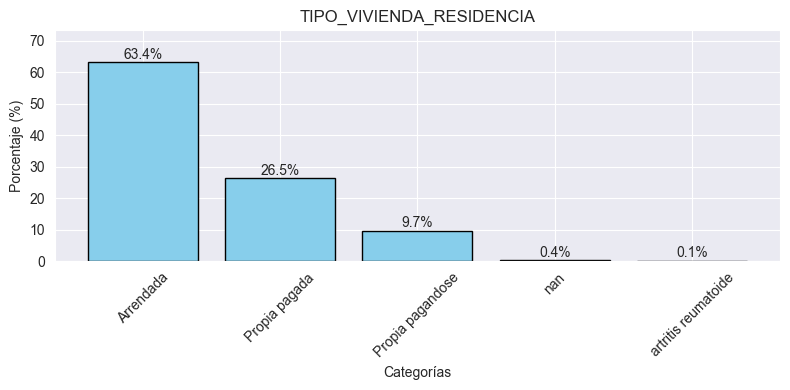

In [57]:
plot_categorical_summary(df_caracterizacion,'TIPO_VIVIENDA_RESIDENCIA')

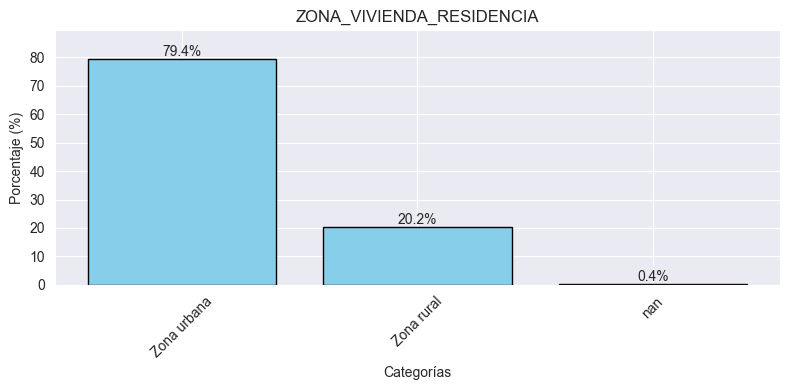

In [60]:
plot_categorical_summary(df_caracterizacion,'ZONA_VIVIENDA_RESIDENCIA')

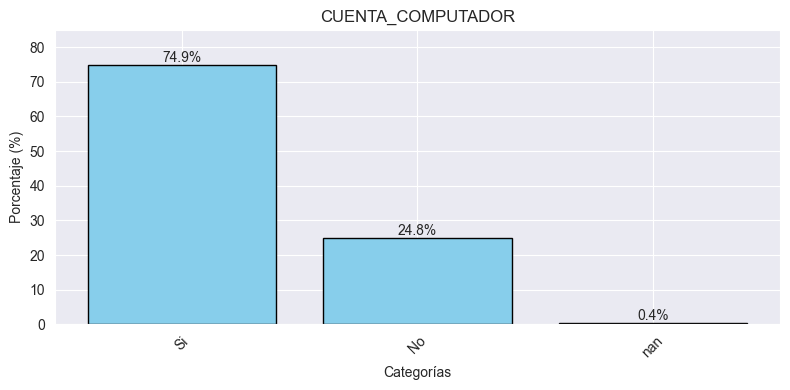

In [62]:
plot_categorical_summary(df_caracterizacion,'CUENTA_COMPUTADOR')


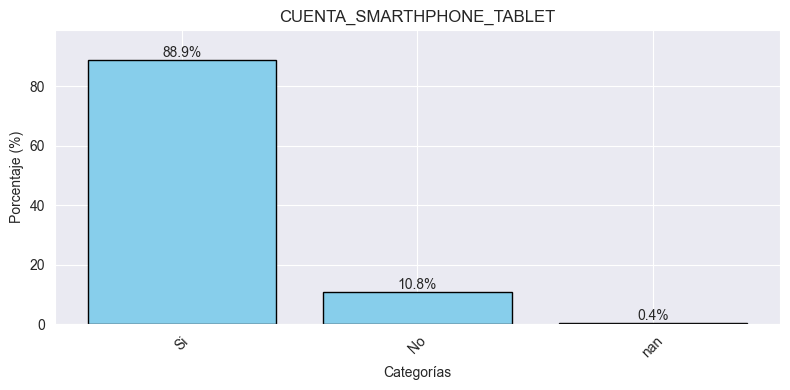

In [63]:
plot_categorical_summary(df_caracterizacion,'CUENTA_SMARTHPHONE_TABLET')

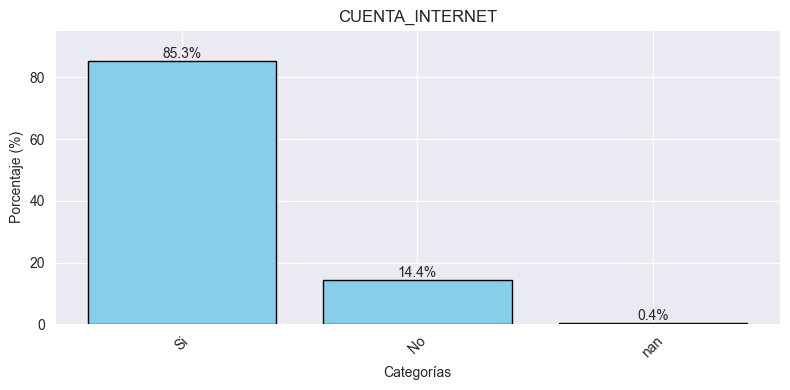

In [74]:
plot_categorical_summary(df_caracterizacion,'CUENTA_INTERNET')

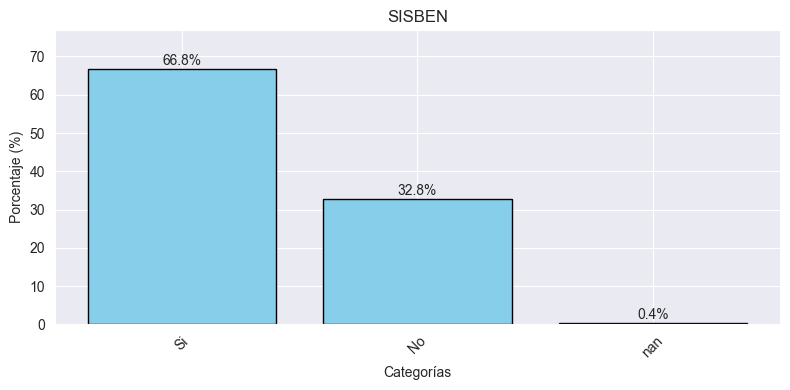

In [75]:
plot_categorical_summary(df_caracterizacion,'SISBEN')


In [76]:
df_caracterizacion['EPS'].value_counts()

EPS
Famisanar              133
famisanar               80
Sanitas                 71
sanitas                 43
Nueva EPS               42
                      ... 
Servisalud San Jose      1
famisanarFamisanar       1
COMPENSAR SALUD          1
Famisnar                 1
sanias                   1
Name: count, Length: 147, dtype: int64

se decide eliminar la variable EPS ya que se considera que la variable SISBEN y TIPO_USUARIO_EPS brindan igual o mejor información que EPS

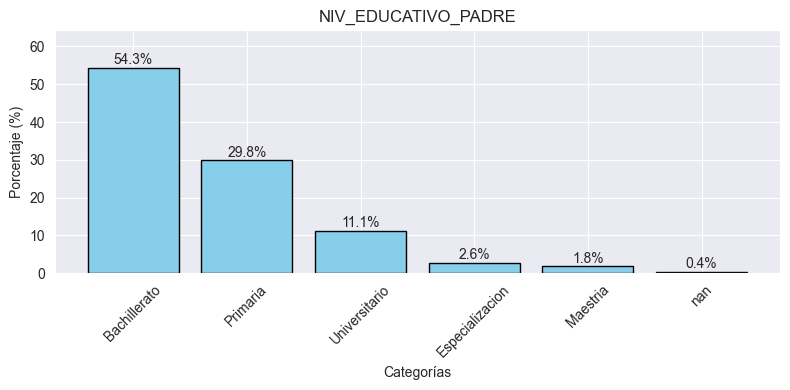

In [77]:
plot_categorical_summary(df_caracterizacion,'NIV_EDUCATIVO_PADRE')


In [78]:
def agrupar_nivel(nivel):
    if nivel in ['Primaria']:
        return 'Básica'
    elif nivel in ['Bachillerato']:
        return 'Media'
    else:
        return 'Superior'

df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_PADRE'].apply(agrupar_nivel)

C:\Users\User\AppData\Local\Temp\ipykernel_624\427981655.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_PADRE'].apply(agrupar_nivel)


In [79]:
df_caracterizacion['NIV_EDUCATIVO_PADRE_CAT'].value_counts()

NIV_EDUCATIVO_PADRE_CAT
Media       453
Básica      249
Superior    133
Name: count, dtype: int64

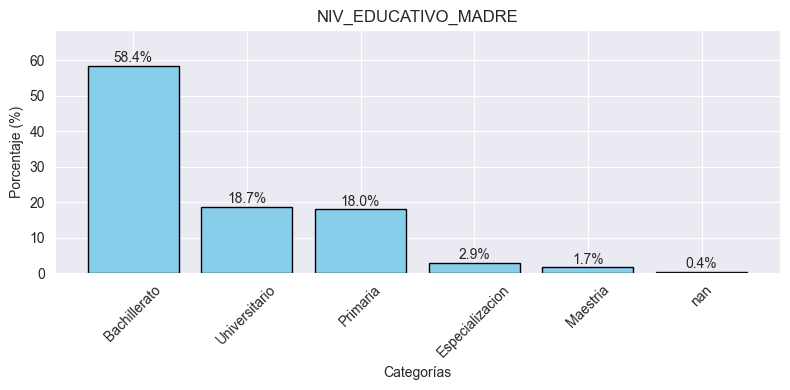

In [80]:
plot_categorical_summary(df_caracterizacion,'NIV_EDUCATIVO_MADRE')

C:\Users\User\AppData\Local\Temp\ipykernel_624\1330150647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['NIV_EDUCATIVO_MADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_MADRE'].apply(agrupar_nivel)


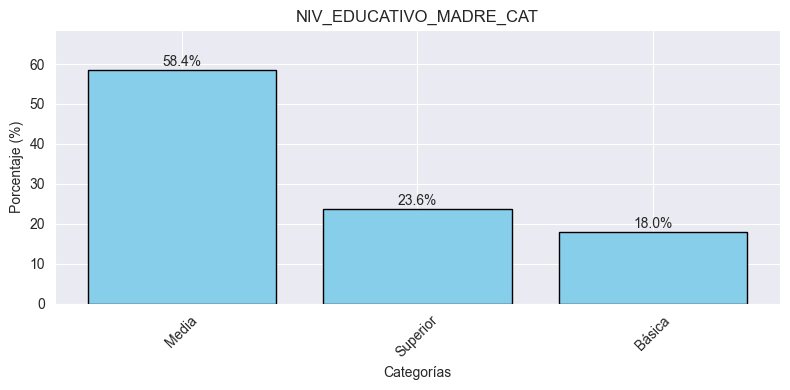

In [82]:
df_caracterizacion['NIV_EDUCATIVO_MADRE_CAT'] = df_caracterizacion['NIV_EDUCATIVO_MADRE'].apply(agrupar_nivel)
plot_categorical_summary(df_caracterizacion, 'NIV_EDUCATIVO_MADRE_CAT')

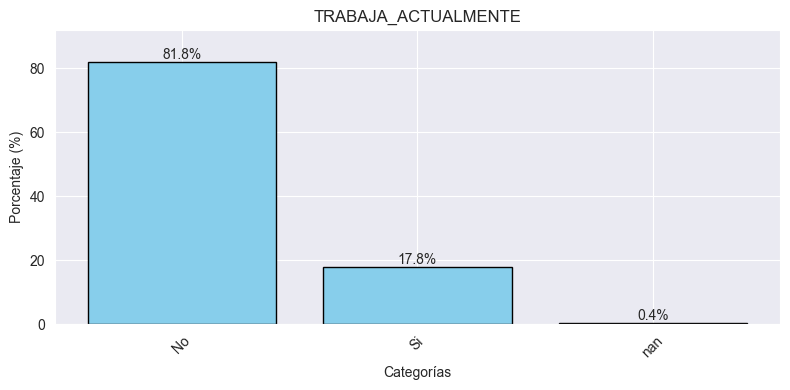

In [83]:
plot_categorical_summary(df_caracterizacion,'TRABAJA_ACTUALMENTE')

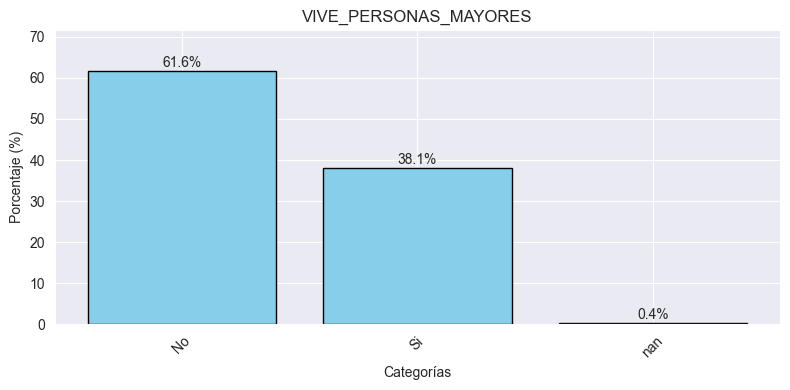

In [84]:
plot_categorical_summary(df_caracterizacion,'VIVE_PERSONAS_MAYORES')

In [86]:

# Limpieza básica: convertimos NaN a 'No reporta'
df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].fillna('No reporta')

# Variable binaria: vive o no con personas con patologías
df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].apply(
    lambda x: 'Sí' if x not in ['No reporta', 'Ninguna'] else 'No'
)

C:\Users\User\AppData\Local\Temp\ipykernel_624\461450971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].fillna('No reporta')
C:\Users\User\AppData\Local\Temp\ipykernel_624\461450971.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'] = df_caracterizacion['VIVE_PERSONAS_PATOLOGIAS'].apply(


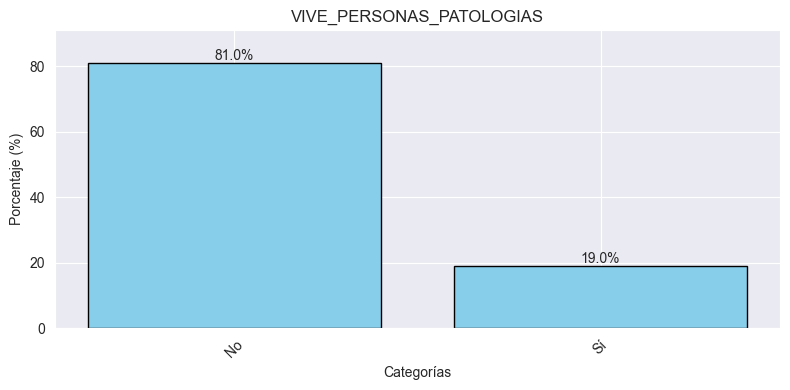

In [87]:
plot_categorical_summary(df_caracterizacion,'VIVE_PERSONAS_PATOLOGIAS')


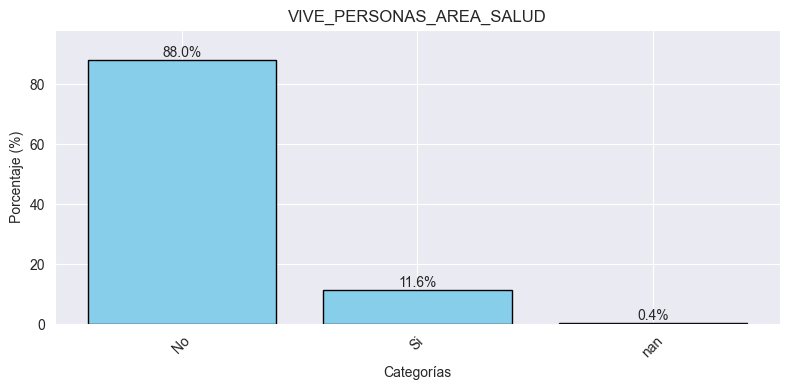

In [88]:
plot_categorical_summary(df_caracterizacion,'VIVE_PERSONAS_AREA_SALUD')


In [93]:
df_caracterizacion['ES_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].apply(
    lambda x: 'Sí' if pd.notnull(x) else 'No')

df_caracterizacion['GRUPO_POBLACION_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].fillna('No reportado')


C:\Users\User\AppData\Local\Temp\ipykernel_624\2992585874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ES_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_624\2992585874.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['GRUPO_POBLACION_VULNERABLE'] = df_caracterizacion['GRUPO_POBLACION_VULNERABLE'].fillna('No reportado')


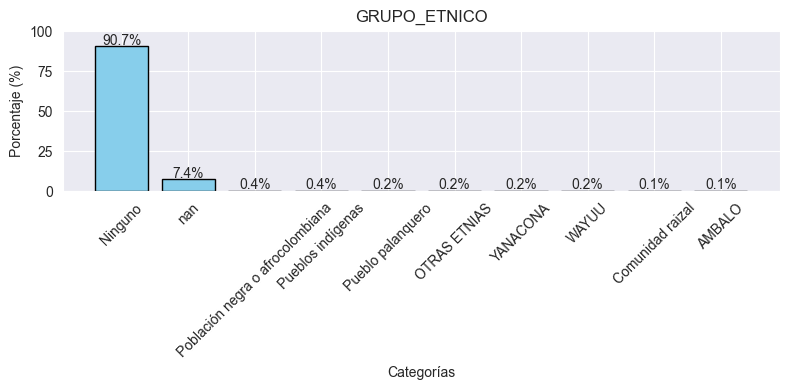

In [127]:
plot_categorical_summary(df_caracterizacion,'GRUPO_ETNICO')


In [128]:
df_caracterizacion['ES_GRUPO_ETNICO'] = df_caracterizacion['GRUPO_ETNICO'].apply(
    lambda x: 'Sí' if x != 'Ninguno' and pd.notnull(x) else 'No'
)

C:\Users\User\AppData\Local\Temp\ipykernel_624\1403990048.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['ES_GRUPO_ETNICO'] = df_caracterizacion['GRUPO_ETNICO'].apply(


In [153]:
df_caracterizacion['GRUPO_ETNICO_CAT'] = df_caracterizacion['GRUPO_ETNICO'].replace({
    'Pueblos indígenas': 'Étnico',
    'Población negra o afrocolombiana': 'Étnico',
    'Comunidad raizal': 'Étnico',
    'Pueblo palanquero': 'Étnico',
    'Ninguno': 'No étnico',
    'OTRAS ETNIAS': 'Étnico',
    'WAYUU': 'Étnico',
    'YANACONA': 'Étnico',
    'AMBALO': 'Étnico'
}).fillna('No reportado')

C:\Users\User\AppData\Local\Temp\ipykernel_624\4141498255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_caracterizacion['GRUPO_ETNICO_CAT'] = df_caracterizacion['GRUPO_ETNICO'].replace({


In [154]:
df_caracterizacion['GRUPO_ETNICO_CAT'].value_counts()

GRUPO_ETNICO_CAT
No étnico       757
No reportado     62
Étnico           16
Name: count, dtype: int64

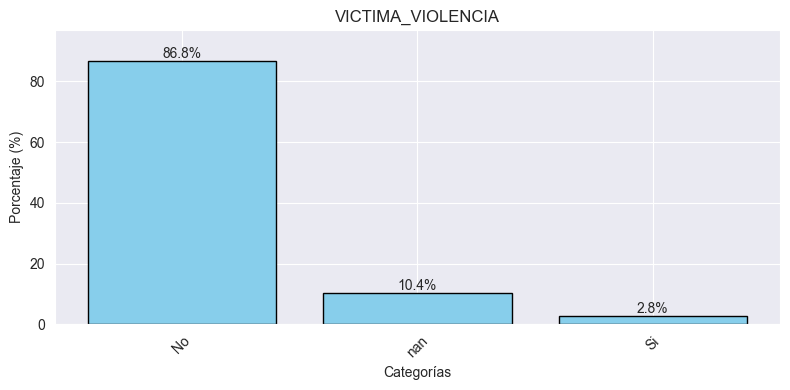

In [155]:
    plot_categorical_summary(df_caracterizacion,'VICTIMA_VIOLENCIA')

In [ ]:
'TIPO_DOCUMENTO', 'ORIENTACION_SEXUAL',EPS, NIV_EDUCATIVO_PADRE, NIV_EDUCATIVO_MADRE, GRUPO_POBLACION_VULNERABLE, 'GRUPO_ETNICO'